what is classification problem?

binary classification

multiclass classification

multilabel classification


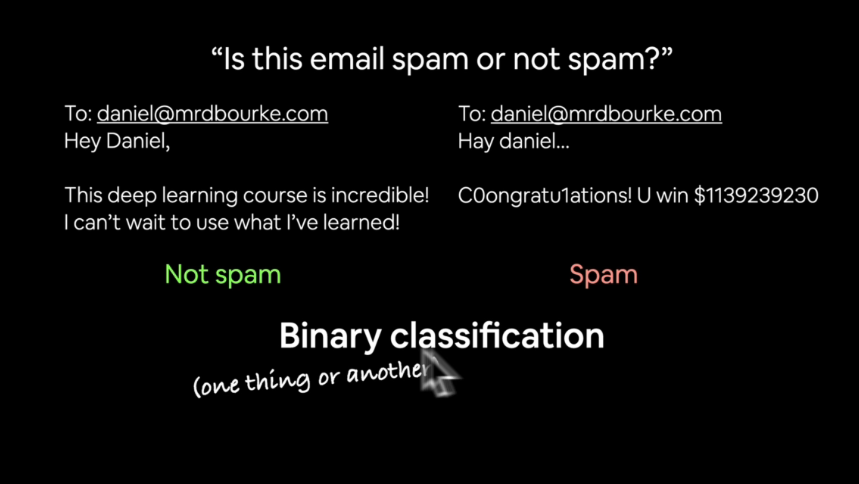

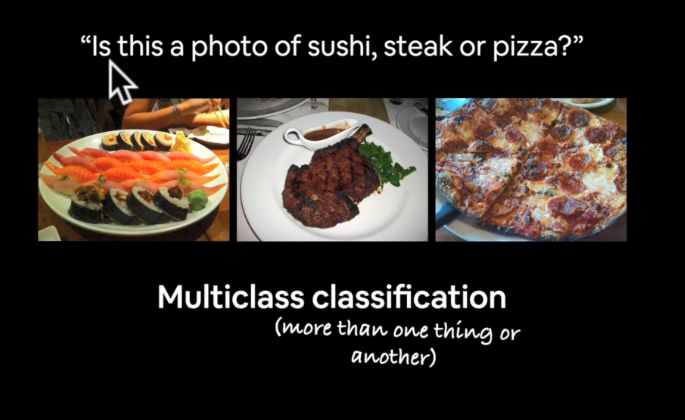

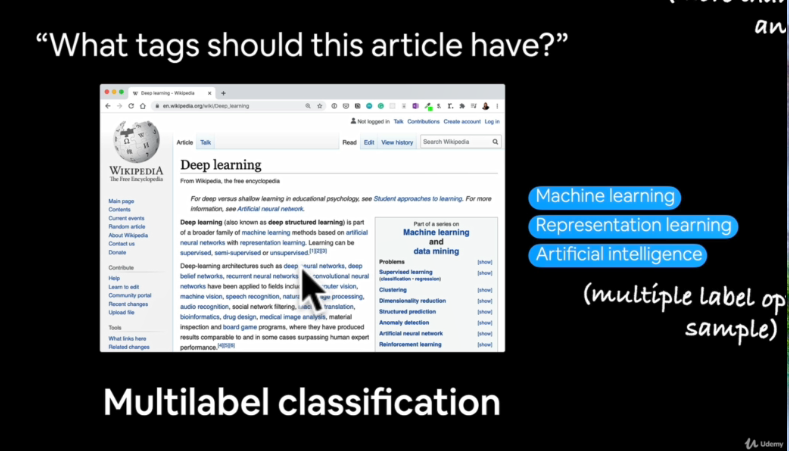

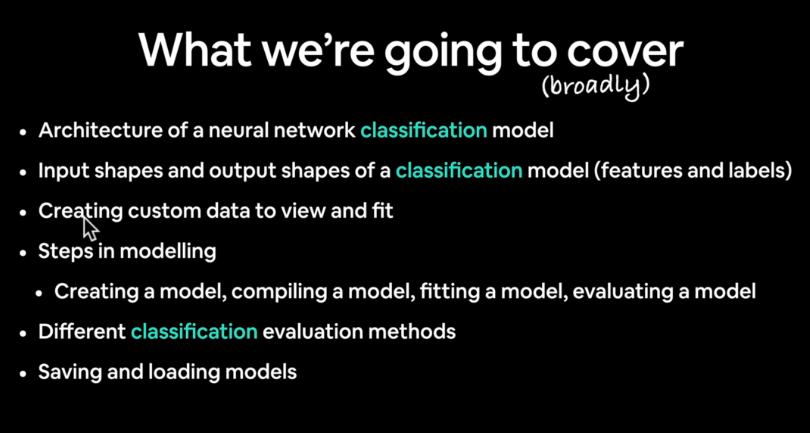

<h1 style="color:red">lec 002:-Example classification problems (and their inputs and outputs).mp4</h1>

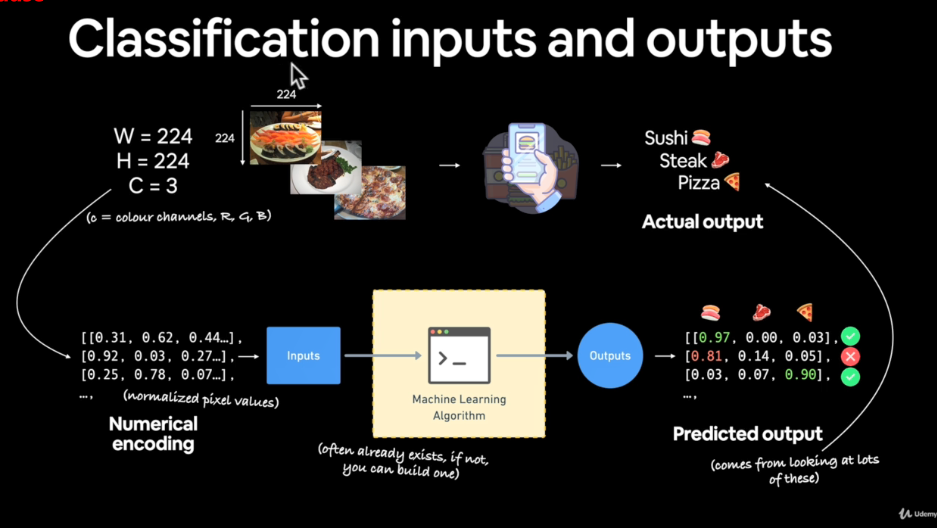

<h1 style="color:red">lec 003:-Input and output tensors of classification problems.mp4</h1>

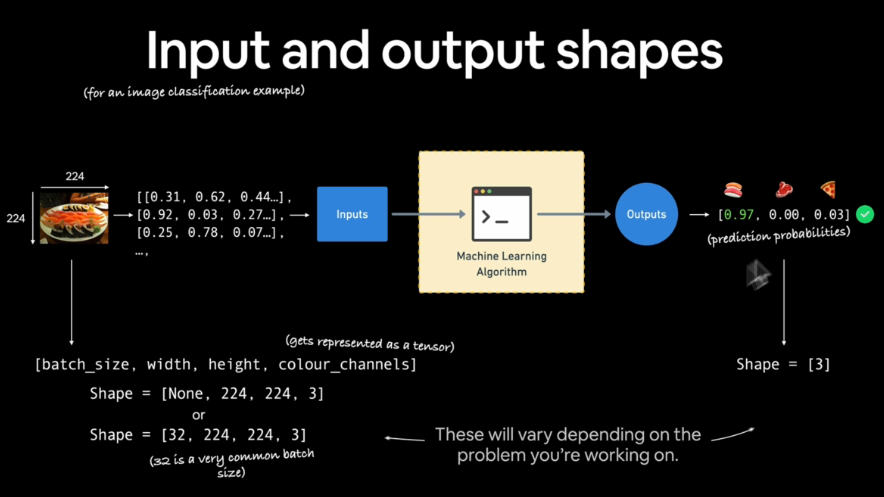

<h1 style="color:red">lec 004:-Typical architecture of neural network classification models with TensorFlow.mp4</h1>

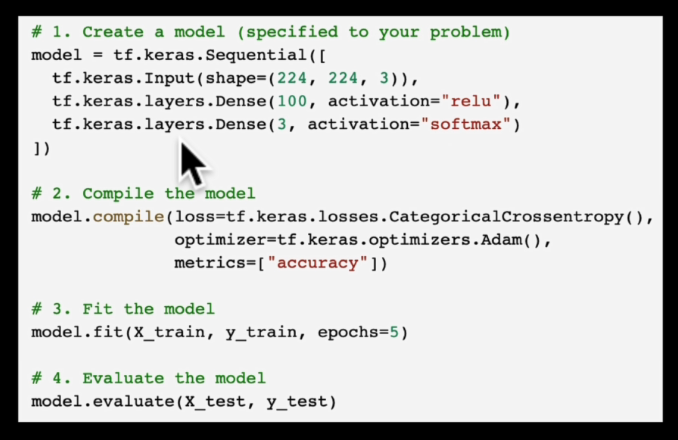

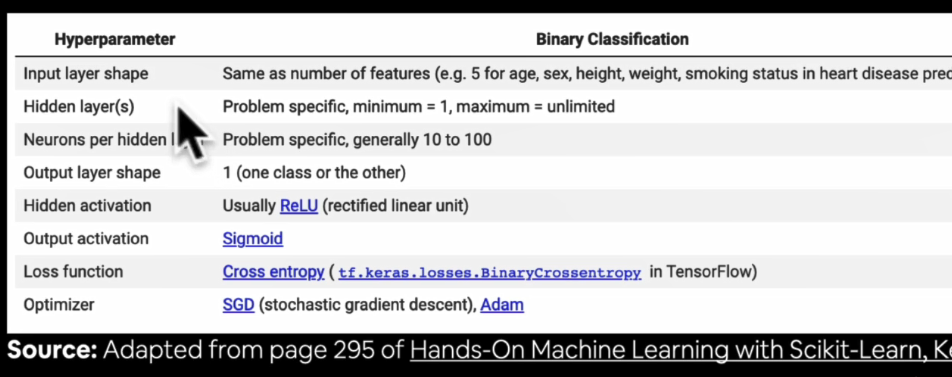

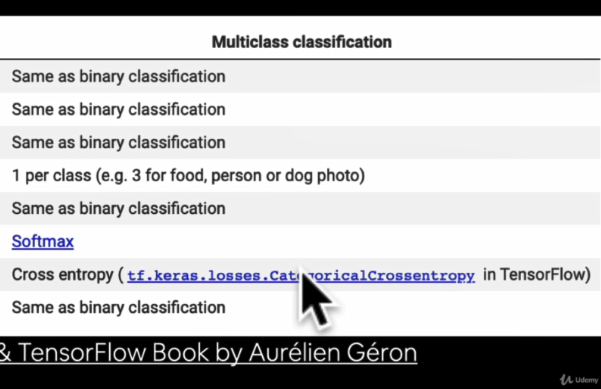

[neural network recipe by andrei karpathy](https://karpathy.github.io/2019/04/25/recipe/)

<h1 style="color:red">lec 005:-Creating and viewing classification data to model.mp4</h1>

# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification problems.

A classification is where you try to classify something as one thing or another.

A few types of classification problems:
* Binary classification
* Multiclass classification
* Multilabel classification

## Creating data to view and fit

In [1]:
from sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)


In [2]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [3]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Our data is a little hard to understand right now... let's visualize it!

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:,0],"X1":X[:,1],"label":y})
circles.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


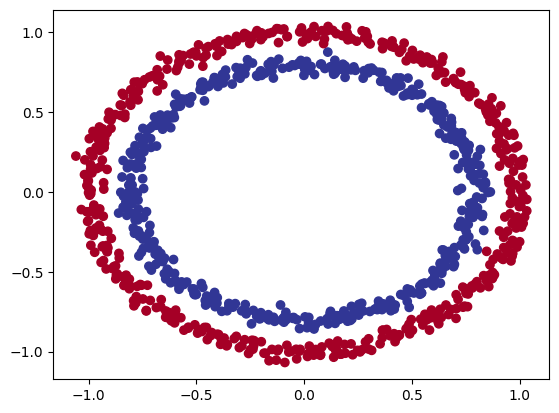

In [5]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu);

**Exercise:**[Neural Network Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.11997&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) :- Spend 10 minutes here.

## Input and output shapes

In [6]:
# Check the shapes of our features and labels
X.shape,y.shape

((1000, 2), (1000,))

In [7]:
# How many samples we're working
len(X), len(y)

(1000, 1000)

In [8]:
# View the first example of features and labels
X[0],y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

<h1 style="color:red">lec 007:-Building a not very good classification model with TensorFlow</h1>

## Steps in modelling

The steps in modelling with TensorFlow are typically:

1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate...

In [9]:
import tensorflow as tf
import numpy as np

# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# 2. Compile a model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# 3. Fit the model
model_1.fit(X,y,epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5099 - loss: 0.6901
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5126 - loss: 0.6871
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5174 - loss: 0.6856
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4881 - loss: 0.6836
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4883 - loss: 0.6814


In [10]:
# Let's try and improve our model by training for longer...
model_1.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4968 - loss: 0.6791
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5183 - loss: 0.6765
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5475 - loss: 0.6736
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5972 - loss: 0.6707
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6446 - loss: 0.6676
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6824 - loss: 0.6642
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7147 - loss: 0.6602
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7539 - loss: 0.6561
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7752 - loss: 0.6520
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8131 - loss: 0.6476
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8416 - loss: 0.6430
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy

Since we're working on a binary classification problem and our teacher model is getting around ~50% accuracy... but ours is 100% but let's follow all other videos to learn new things

oh, we've already added an extra layer so let's just watch the video.

also we evaluated our data only based on training examples not on test examples so that's why our result seems better.

<h1 style="color:red">lec 008:-Trying to improve our not very good classification model.mp4</h1>

## Improving our model

Let's look into our bag of tricks to see how we can improve our model.

1. Create a model - we might to add more layers or increase the number of hidden units within a layer or change/choose a activation function such as relu.
2. Compiling a model - here we might to choose a different optimization function such as Adam instead of SGD.
3. Ftting a model - perhaps we might fit our model for more epochs (leave it training for longer).

<h1 style="color:red">lec 009:-Creating a function to view our model's not so good predictions.mp4</h1>

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:

* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make predictions accross the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falls)

In [11]:
import numpy as np

In [12]:


def plot_decision_boundary(model,X,y):
    """
    Plots the decision boundary created by a model predicting X.
    This function was inspired by two resources:
     1. https://cs231n.github.io/neural-networks-case-study/
     2. https://scikit-learn.org/stable/auto_examples/svm/plot_iris.html
     3. https://github.com/mikefil93/madewithML-basics
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min,x_max = X[:,0].min() - 0.1, X[:,0].max() +0.1
    y_min,y_max = X[:,1].min() - 0.1, X[:,1].max() +0.1

    xx,yy = np.meshgrid(np.linspace(x_min,x_max),
                        np.linspace(y_min,y_max))

    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(),yy.ravel()] # stack 2D arrays together .ravel() convert Ndarray to 1Darray

    # Make predictions
    y_pred = model.predict(x_in)

    # Check for multi-class
    if len(y_pred[0])>1:
      print("doing multiclass classification")
      # We have to reshape our predictions to get them ready for plotting
      y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
    else:
      print("doing binary classification")
      y_pred = np.round(y_pred).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7)
    plt.scatter(X[:,0],X[:,1],c=y , s=40,cmap = plt.cm.RdYlBu)
    plt.xlim(xx.min(),xx.max())
    plt.ylim(yy.min(),yy.max())

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
doing binary classification


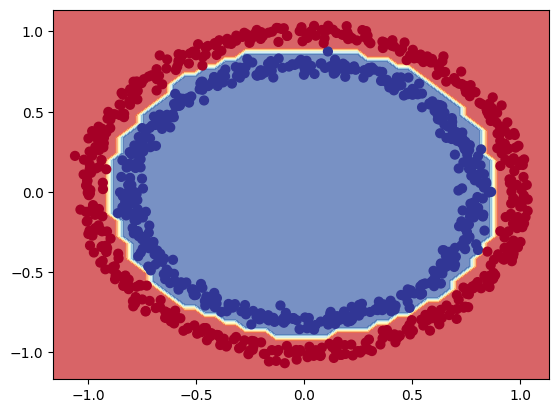

In [13]:
# Check out the predictions our model is making
plot_decision_boundary(model_1,X,y)

[To understand above code CS231n neural network case study](https://cs231n.github.io/neural-networks-case-study/)

`np.meshgrid` creates **coordinate grids from coordinate vectors**.
Used for evaluating functions over a grid, plotting surfaces, decision boundaries, etc.

---

## Core idea

Given 1D arrays:

```python
x = [x1, x2, x3]
y = [y1, y2]
```

`np.meshgrid(x, y)` produces **2D matrices** where:

* One matrix repeats `x` across rows
* The other repeats `y` down columns

---

## Simple example

```python
import numpy as np

x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)
```

### Output

```python
X =
[[1 2 3]
 [1 2 3]]

Y =
[[10 10 10]
 [20 20 20]]
```

Each `(X[i,j], Y[i,j])` is a **coordinate pair**.

---

## Why this is useful

### 1. Evaluate a function on a grid

```python
Z = X + Y
```

```
[[11 12 13]
 [21 22 23]]
```

---

### 2. Plot decision boundaries / surfaces

Used heavily with:

* `matplotlib`
* ML classifiers
* regression surfaces

Example:

```python
xx, yy = np.meshgrid(
    np.linspace(-5, 5, 100),
    np.linspace(-5, 5, 100)
)
```

Creates a **100×100 grid** of coordinates.

---

## Shape logic (important)

If:

```python
x.shape = (n,)
y.shape = (m,)
```

Then:

```python
X.shape = (m, n)
Y.shape = (m, n)
```

---

## Indexing modes

### Default (`indexing="xy"`)

Cartesian coordinates (used in plotting)

```python
np.meshgrid(x, y)
```

### Matrix indexing (`indexing="ij"`)

```python
np.meshgrid(x, y, indexing="ij")
```

Shapes become:

```python
X.shape = (n, m)
Y.shape = (n, m)
```

Used in numerical computing.

---

## Common ML use case (decision boundary)

```python
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid)
Z = preds.reshape(xx.shape)
```

---

## Mental model

* `meshgrid` = **expand axes**
* Turns vectors into coordinate matrices
* Enables vectorized computation over space

---

## Summary

| Concept | Meaning                        |
| ------- | ------------------------------ |
| Input   | 1D coordinate arrays           |
| Output  | Coordinate matrices            |
| Use     | Surfaces, plots, ML boundaries |
| Shape   | `(len(y), len(x))` by default  |

If you want, I can show **how it connects to TensorFlow models and plotting predictions**.


`np.c_` is **NumPy’s column-wise concatenation helper**.

### What it does

It **stacks arrays as columns** (along axis=1).

### Basic idea

```python
np.c_[a, b, c]
```

→ combines `a`, `b`, `c` **side by side** into a 2D array.

### Examples

#### 1. Convert 1D array to 2D column

```python
x = np.array([1, 2, 3])
np.c_[x]
```

Result:

```
[[1],
 [2],
 [3]]
```

Same as:

```python
x.reshape(-1, 1)
```

#### 2. Combine multiple columns

```python
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

np.c_[x, y]
```

Result:

```
[[1 4],
 [2 5],
 [3 6]]
```

#### 3. With pandas-style ML usage

```python
X = np.c_[df["GDP per capita"], df["Life satisfaction"]]
```

Creates a feature matrix with 2 columns.

### Why it’s used in ML

* Quickly build **feature matrices**
* Ensures **2D shape** `(n_samples, n_features)`
* Cleaner than `reshape` + `concatenate`

### Equivalent long form

```python
np.concatenate([x.reshape(-1,1), y.reshape(-1,1)], axis=1)
```

### Summary

* `np.c_` = column stack
* Converts 1D → 2D
* Combines features horizontally
* Common in regression and TensorFlow preprocessing


Here’s a complete, structured summary of your `plot_decision_boundary` function, including all the explanations and clarifications from your questions. You can directly use this in documentation:

---

## **Function Summary: `plot_decision_boundary`**

### **Purpose**

Visualizes the decision boundary of a classifier in 2D feature space by showing regions of predicted classes and overlaying the original data points.

---

### **Working Principle**

1. Generates a dense **grid of points** covering the feature space of `X`.
2. Predicts class labels for every point in the grid using `model.predict()`.
3. Colors regions according to predicted labels.
4. The **decision boundary** appears at the edges where predicted labels change.
5. Overlays the actual data points to compare predictions vs. ground truth.

**Mathematical Principle:**

* Binary classification boundary:
  [
  \text{Decision boundary} = {(x, y) \mid f(x, y) = 0.5}
  ]
* Multi-class boundary:
  [
  \text{Decision boundary} = {(x, y) \mid \arg\max f(x, y) \text{ changes between classes}}
  ]
* These boundaries are **infinitesimally thin curves**, but are approximated by discrete grid points in the plot.

---

### **Line-by-Line Explanation**

```python
x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
y_min, y_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
```

* Defines the plot boundaries with a small padding.

```python
xx, yy = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
```

* Creates a **2D grid of points** covering the feature space.
* `xx[i,j]` and `yy[i,j]` give the coordinates of each grid point.
* 2D structure is required so `contourf` knows how to connect neighboring points.

```python
x_in = np.c_[xx.ravel(), yy.ravel()]
```

* Converts 2D grid into a list of points for prediction (`shape = num_points × 2`).

```python
y_pred = model.predict(x_in)
```

* Predicts class labels or probabilities for every grid point.

```python
if len(y_pred[0]) > 1:
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
else:
    y_pred = np.round(y_pred).reshape(xx.shape)
```

* Handles **multi-class** vs **binary** predictions.
* Reshapes `y_pred` to match the grid for plotting.

```python
plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
```

* Uses **`contourf`** to fill regions with colors according to `y_pred`.
* `contourf` detects edges where `y_pred` changes and draws **decision boundaries**.
* The edges are infinitesimally thin mathematically; visual width comes from grid resolution.

```python
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
```

* Plots actual data points over the colored regions.
* Sets plot limits to match the grid boundaries.

---

### **Key Concepts & Answers to Questions**

1. **Edges / Decision Boundary**

   * Formed where predicted class changes between neighboring grid points.
   * Infinitesimally thin mathematically, discrete in visualization.

2. **Why Z is 2D**

   * `Z` corresponds to predicted labels on the 2D grid.
   * Each `Z[i,j]` maps to a specific `(xx[i,j], yy[i,j])` point.
   * 1D `Z` cannot form contours because there’s no grid structure.

3. **Why xx, yy are 2D**

   * They represent **all x and y coordinates of the grid**.
   * 2D shape allows `contourf` to find neighbors and draw smooth edges.

4. **`contourf`**

   * Fills regions between contours of equal values.
   * Automatically draws edges where `Z` changes value.
   * Used to visualize decision boundaries for classifiers.

---

This summary includes the **function logic, mathematical foundation, and visualization principles**. It can serve as comprehensive documentation for understanding or teaching this function.

---

I can also make a **one-page diagram** showing grid → predictions → filled contours → edges if you want a visual summary for your documentation. Do you want me to create it?


<h1 style="color:red">lec 011:-Non-linearity part 1_ Straight lines and non-straight lines.mp4</h1>

## The missing peice: Non-linearity

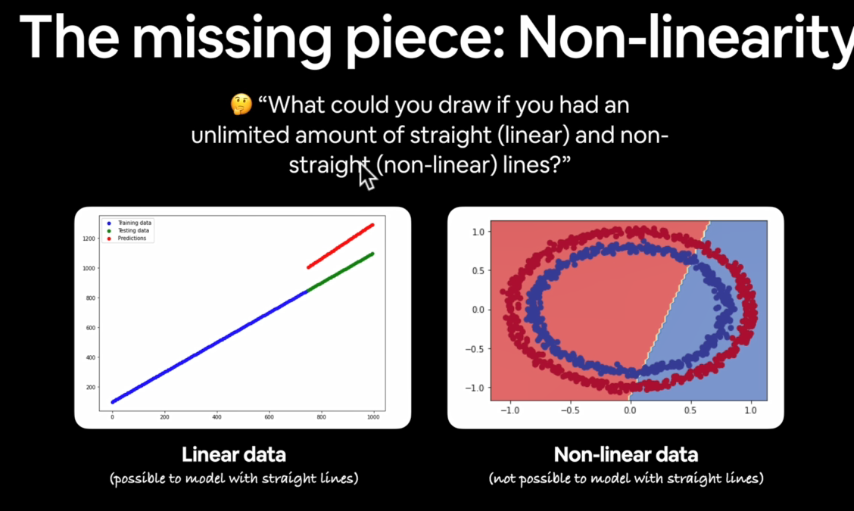

In [14]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
  tf.keras.layers.Dense(1,activation="linear"),
  ])

# 2. Compile the model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# 3. fit the model
history = model_4.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4662 - loss: 5.9574   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4681 - loss: 5.8924
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4667 - loss: 5.8584 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4651 - loss: 5.8113 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4664 - loss: 5.6794
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4662 - loss: 5.6806
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4666 - loss: 5.6612
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4657 - loss: 5.6476
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4657 - loss: 5.6455
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4657 - loss: 5.6443
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4657 - loss: 5.6419
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

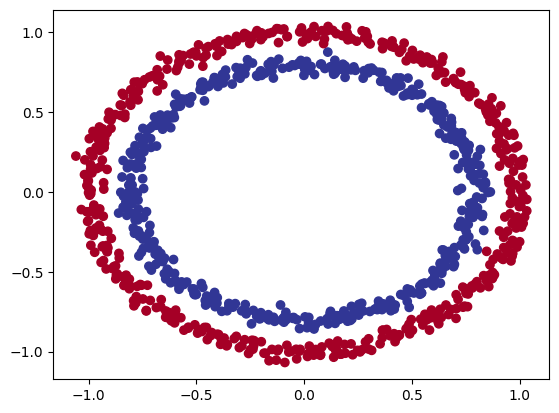

In [15]:
# Check out our data
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification


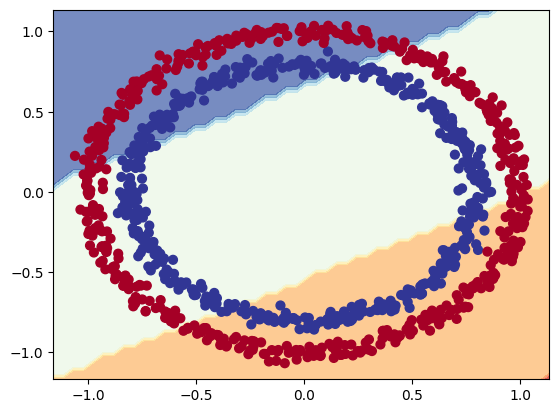

In [16]:
# Check the decision boundary for our latest model
plot_decision_boundary(model_4,X,y)

<h1 style="color:red">lec 012:-Non-linearity part 2_ Building our first neural network with non-linearity.mp4</h1>

Let's try build our first neural network with a non-linear activation function.

In [17]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
  tf.keras.layers.Dense(1,activation="relu"),
  ])

# 2. Compile the model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# 3. fit the model
history = model_5.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4902 - loss: 5.5701   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4881 - loss: 5.5326
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4851 - loss: 5.4660
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4864 - loss: 5.4069
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4856 - loss: 5.3770
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4826 - loss: 5.3610
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4826 - loss: 5.3324
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4790 - loss: 5.2830
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4817 - loss: 5.2054
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4817 - loss: 5.1974
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4817 - loss: 5.1835
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accura

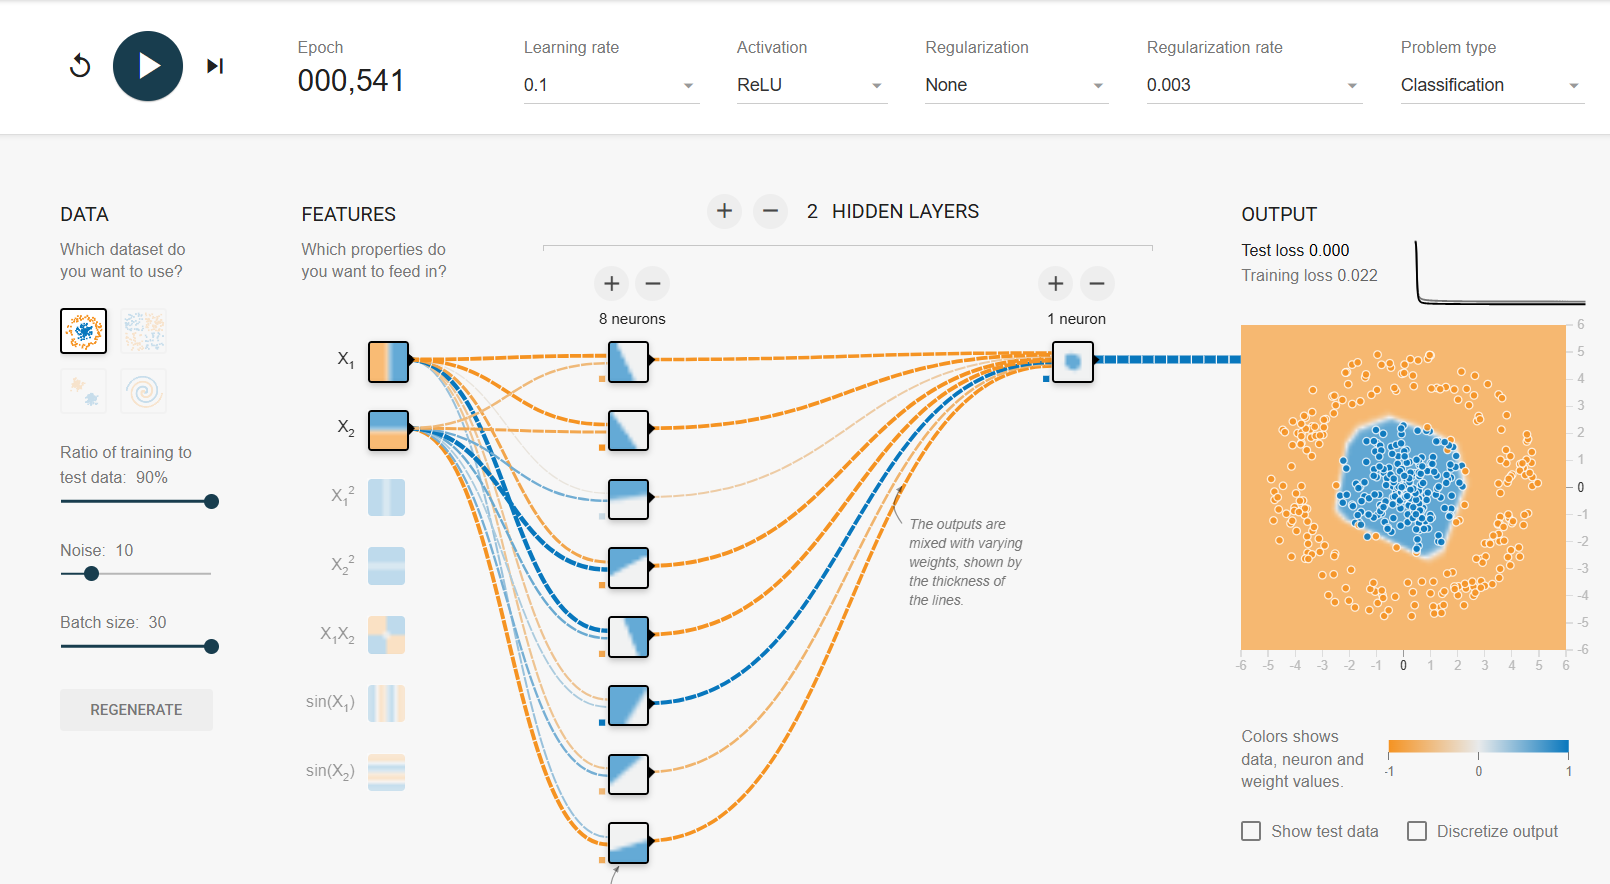

<h1 style="color:red">lec 013:-Non-linearity part 3_ Upgrading our non-linear model with more layers.mp4</h1>

In [18]:
# Time to replicate the multi-layer neural network from TensorFlow playground in code...

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
  tf.keras.layers.Dense(8,activation="relu"),
  tf.keras.layers.Dense(1,activation="sigmoid")
  ])

# 2. Compile the model
model_6.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# 3. fit the model
history = model_6.fit(X,y,epochs=200)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5178 - loss: 0.7212
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5090 - loss: 0.7155
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5086 - loss: 0.7117
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5071 - loss: 0.7089
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5039 - loss: 0.7066
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5046 - loss: 0.7046
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4993 - loss: 0.7029
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4947 - loss: 0.7014
Epoch 9/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4854 - loss: 0.7000
Epoch 10/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4839 - loss: 0.6986
Epoch 11/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4818 - loss: 0.6974
Epoch 12/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
doing binary classification


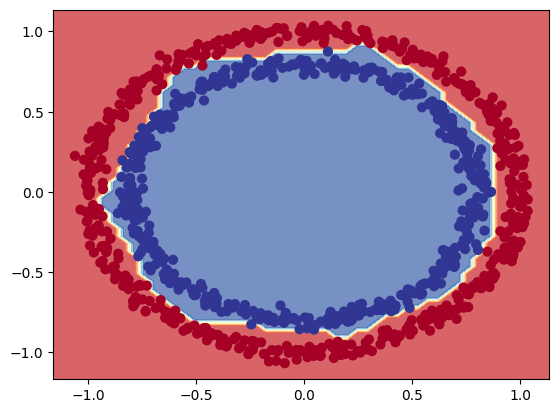

In [19]:
# How do our model predictions look?
plot_decision_boundary(model_6,X,y)

In [20]:
model_6.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9976 - loss: 0.3703  


[0.36785024404525757, 0.9959999918937683]

**Question:** What's wrong the predictions we've made? Are we really evaluating our model correctly? Hint: what data did the model learn on and what data we predict on?

ans:- we evalaute our model on the training data which is wrong. For true evaluation, we have to evaluate our model on the data which our model haven't seen before


**Note:** The combination of **linear (straight lines) and non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

<h1 style="color:red">lec 015:-Non-linearity part 5_ Replicating non-linear activation functions from scratch.mp4</h1>

Now we've discussed the concept of linear and non-linear fuctions (or lines), let's see them in action.

In [21]:
# Create a toy tensor (similar to the data we pass into our models)
A = tf.cast(tf.range(-10,10),tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

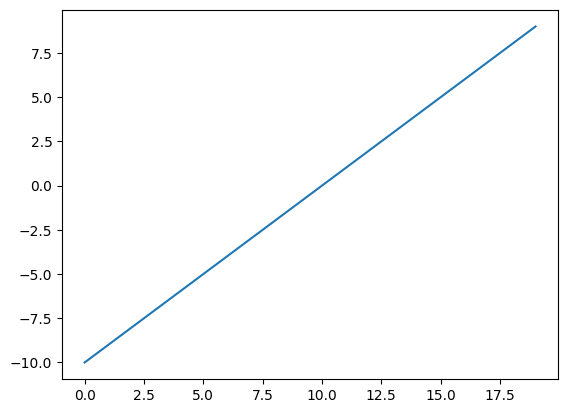

In [22]:
# Visualize our toy tensor
plt.plot(A)

In [23]:
# Let's start by replicating sigmoid - sigmoid(x) = 1/ (1= exp(-x))
def sigmoid(x):
  return 1/(1+ tf.exp(-x))

# Use the sigmoid function on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

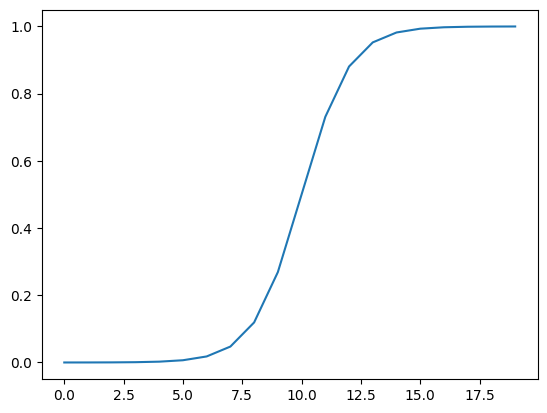

In [24]:
# Plot our toy tensor  transformed by sigmoid
plt.plot(sigmoid(A));

In [25]:
# Let's recreate the relu function
def relu(x):
  return tf.maximum(0,x)

# Pass our toy tensor to our custom relu function
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

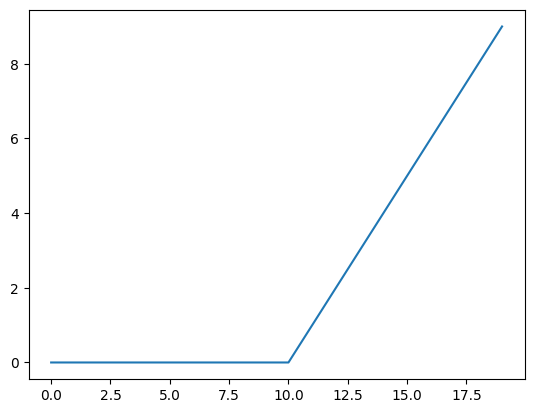

In [26]:
# Plot ReLu-modified tensor
plt.plot(relu(A))

In [27]:
# Let's try the linear activation function
tf.keras.activations.linear(A) # same as before without modification

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

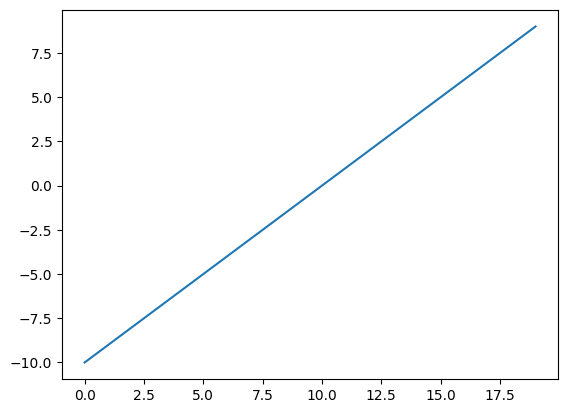

In [28]:
# Does the linear activation function change anything?
plt.plot(tf.keras.activations.linear(A))

In [29]:
# Does A even change?
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

[Machine learning cheatsheet activation function](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html)

<h1 style="color:red">lec 016:-Getting great results in less time by tweaking the learning rate.mp4</h1>

## Evaluating and improving our classifictaion problem

So far we've been training and testing on the same dataset...

However, in machine learning this is basically a sin.

So let's create a training and test set.

In [30]:
# Check how many examples we have
len(X)

1000

In [31]:
# Split the train and test sets (the order is random so no need to shuffle)
X_train, y_train, X_test, y_test = X[:800], y[:800], X[800:], y[800:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 2), (800,), (200, 2), (200,))

In [32]:
# Let's recreate a model yo fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# 2. Compile the model
model_8.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics = ["accuracy"]
)

# 3. Fit the model
history = model_8.fit(X_train,y_train,epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4908 - loss: 0.7099
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5237 - loss: 0.6896 
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5373 - loss: 0.6829 
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5419 - loss: 0.6787 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5485 - loss: 0.6731 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5821 - loss: 0.6652 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6384 - loss: 0.6525 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6920 - loss: 0.6355 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7452 - loss: 0.6105 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7724 - loss: 0.5634 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7884 - loss: 0.5256 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

In [33]:
model_8.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9486 - loss: 0.2117  


[0.2101694494485855, 0.949999988079071]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
doing binary classification
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
doing binary classification


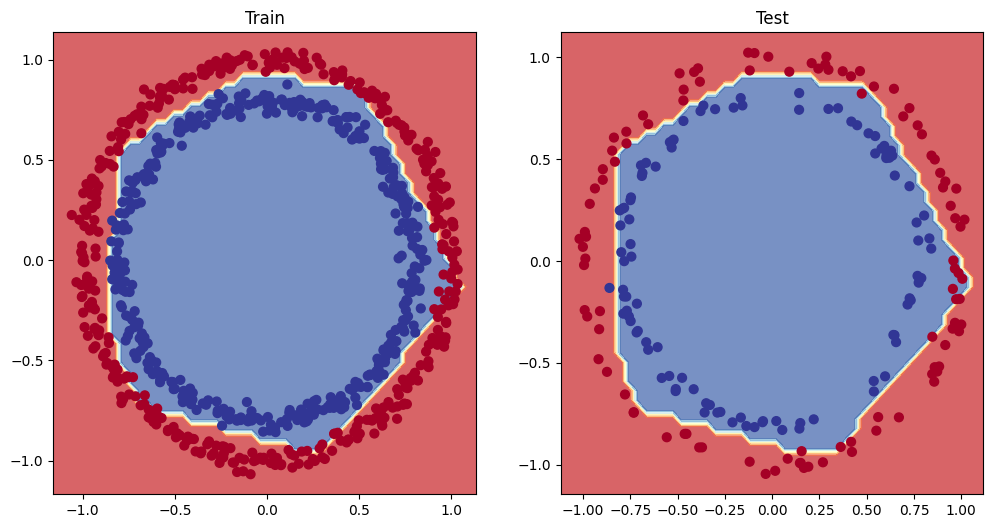

In [34]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_8,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_8,X_test,y_test)

<h1 style="color:red">lec 017:-Using the TensorFlow History object to plot a model's loss curves.mp4</h1>

## Plot the loss (or training) curves

In [35]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,accuracy,loss
0,0.49625,0.701330
1,0.52000,0.687715
2,0.53000,0.682641
3,0.53375,0.677832
4,0.55250,0.671368
5,0.58500,0.662004
6,0.63000,0.647588
7,0.67625,0.629164
8,0.74625,0.596586
9,0.76625,0.553336


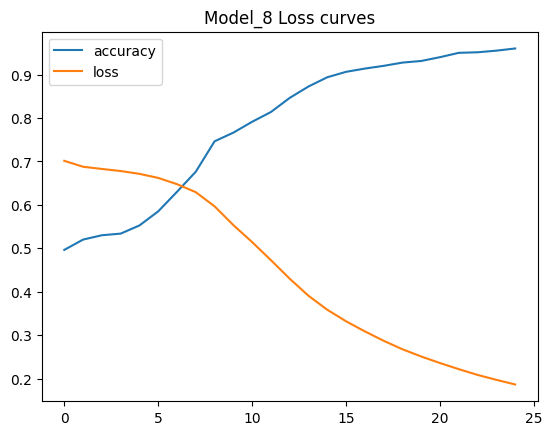

In [36]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 Loss curves")
plt.show()

**Note:** For many problems, the loss function going down means the model is improving (the predictions it's making getting closer to the ground truth labels).

<h1 style="color:red">lec 018:-Using callbacks to find a model's ideal learning rate.mp4</h1>

## Finding the best learning rate

To find the ideal learning rate (the learning rate where loss decreases the most during the training) we're going to use the following steps:
* A learning rate **callback** - you can think of a callback as an extra piece of functionality, you can add to your *while* its training.
* Another model (we could use the same one as above, but we're practicing building models here)
* A modified loss curves plot.



In [37]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_9 = tf.keras.Sequential([
  tf.keras.layers.Dense(4,activation="relu"),
  tf.keras.layers.Dense(4,activation="relu"),
  tf.keras.layers.Dense(1,activation="sigmoid")
  ])

# 2. Compile the model
model_9.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. fit the model
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4968 - loss: 0.7045 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5093 - loss: 0.7037 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5060 - loss: 0.7030 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5063 - loss: 0.7021 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5060 - loss: 0.7013 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5056 - loss: 0.7003 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5047 - loss: 0.6994 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5075 - loss: 0.6984 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5192 - loss: 0.6974 - learning_

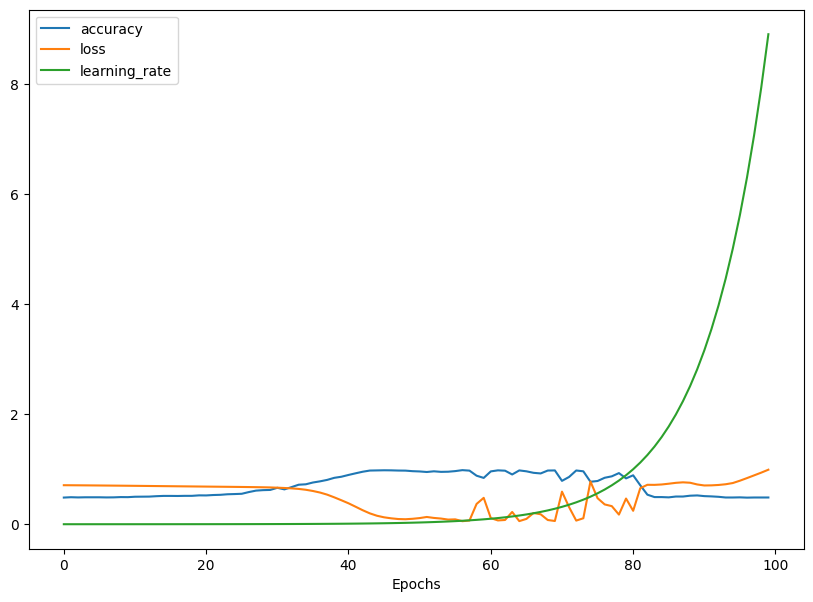

In [38]:
# Checkout the history
pd.DataFrame(history_9.history).plot(figsize=(10,7),xlabel="Epochs")
plt.show()

In [39]:
# Plot the larning rate versus the loss
lrs = 1e-4 * (10**(tf.range(100)/20))
lrs

<tf.Tensor: shape=(100,), dtype=float64, numpy=
array([1.00000000e-04, 1.12201845e-04, 1.25892541e-04, 1.41253754e-04,
       1.58489319e-04, 1.77827941e-04, 1.99526231e-04, 2.23872114e-04,
       2.51188643e-04, 2.81838293e-04, 3.16227766e-04, 3.54813389e-04,
       3.98107171e-04, 4.46683592e-04, 5.01187234e-04, 5.62341325e-04,
       6.30957344e-04, 7.07945784e-04, 7.94328235e-04, 8.91250938e-04,
       1.00000000e-03, 1.12201845e-03, 1.25892541e-03, 1.41253754e-03,
       1.58489319e-03, 1.77827941e-03, 1.99526231e-03, 2.23872114e-03,
       2.51188643e-03, 2.81838293e-03, 3.16227766e-03, 3.54813389e-03,
       3.98107171e-03, 4.46683592e-03, 5.01187234e-03, 5.62341325e-03,
       6.30957344e-03, 7.07945784e-03, 7.94328235e-03, 8.91250938e-03,
       1.00000000e-02, 1.12201845e-02, 1.25892541e-02, 1.41253754e-02,
       1.58489319e-02, 1.77827941e-02, 1.99526231e-02, 2.23872114e-02,
       2.51188643e-02, 2.81838293e-02, 3.16227766e-02, 3.54813389e-02,
       3.98107171e-02, 4.4668

In [40]:
len(lrs)

100

Text(0.5, 1.0, 'Learning Rate vs Loss')

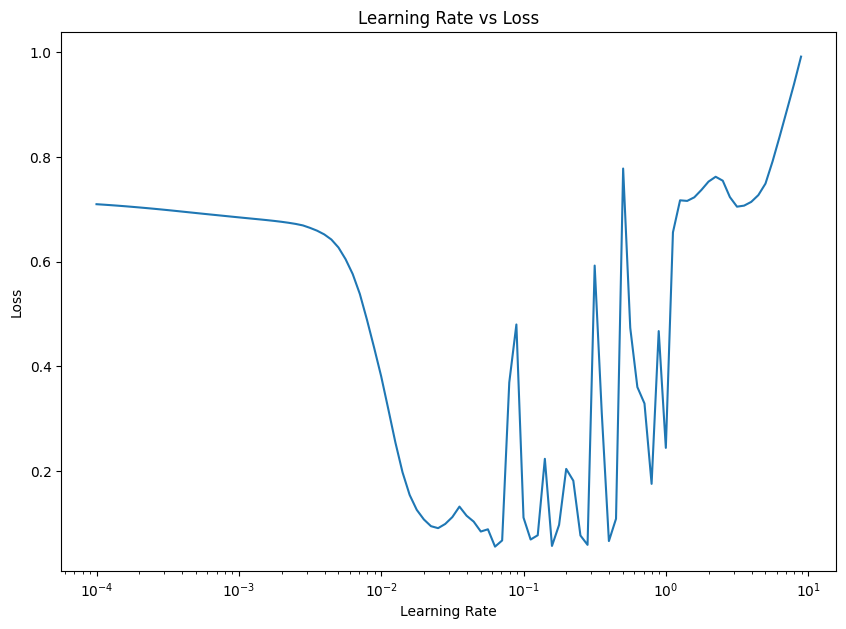

In [41]:
plt.figure(figsize=(10,7))
plt.semilogx(lrs,history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")

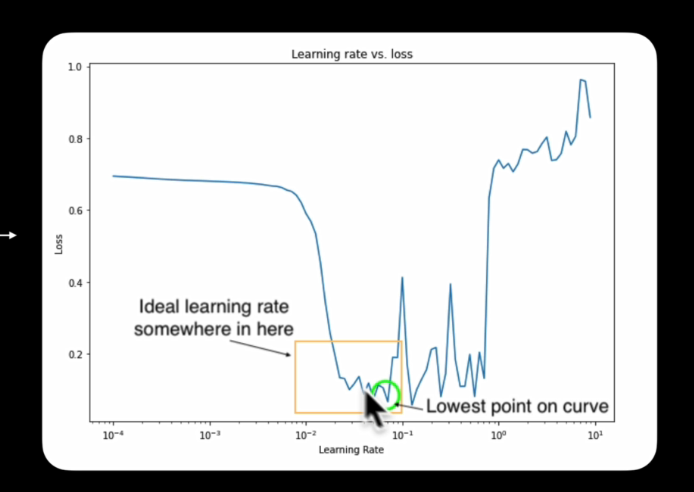

In [42]:
# Example of other typical learning rates values
10**0,10**-1,10**-2,10**-3,1e-4

(1, 0.1, 0.01, 0.001, 0.0001)

the good range is between 0.1 - 0.01

<h1 style="color:red">lec 019:-Training and evaluating a model with an ideal learning rate.mp4</h1>

In [43]:
# Lowest point on that curve is in between 0.03 and 0.04

# Let's use our 0.03 learning rate

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# 2. Compile the model
model_10.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.02),
    metrics = ["accuracy"]
)

# 3. Fit the model for 20 epochs (5 less than before)
history_10 = model_10.fit(X_train,y_train,epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4730 - loss: 0.7037
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5033 - loss: 0.6914 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5093 - loss: 0.6882 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5364 - loss: 0.6838 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5273 - loss: 0.6793 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5434 - loss: 0.6723 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5508 - loss: 0.6644 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5512 - loss: 0.6589 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5633 - loss: 0.6515 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5713 - loss: 0.6484 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5783 - loss: 0.6430 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

In [44]:
# Evaluate model 10 on the test dataset
model_10.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6470 - loss: 0.6191  


[0.6255836486816406, 0.6000000238418579]

In [45]:
# Evaluate model 8 on the test dataset
model_8.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9486 - loss: 0.2117 


[0.2101694494485855, 0.949999988079071]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
doing binary classification
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


Text(0.5, 1.0, 'Model_10 Test Data')

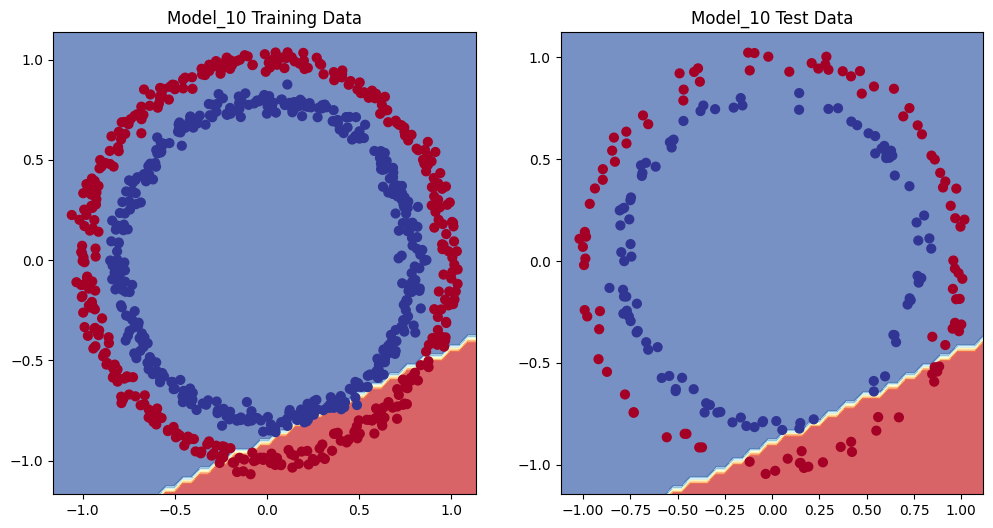

In [46]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plot_decision_boundary(model_10,X_train,y_train)
plt.title("Model_10 Training Data")
plt.subplot(1,2,2)
plot_decision_boundary(model_10,X_test,y_test)
plt.title("Model_10 Test Data")

<h1 style="color:red">lec 020:-Introducing more classification evaluation methods.mp4</h1>

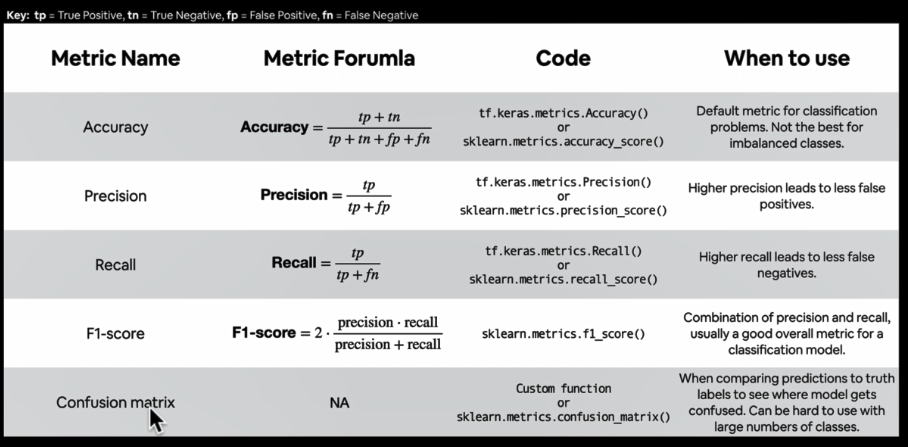

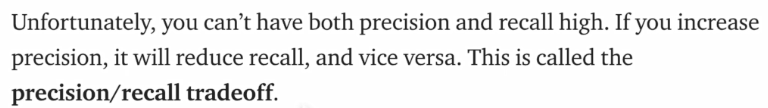

<h1 style="color:red">lec 021:-Finding the accuracy of our classification model.mp4</h1>

## More classification evaluation methods

Alongside visualizing our models results as much as possible, there are a handful of other classification evaluation methods & metrics you should be familiar with:
* Accuracy
* Precision
* F1-score
* Confusion matrix
* Classification report (from scikit-learn) - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [47]:
# Check the accuracy of our model
loss, accuracy = model_10.evaluate(X_test,y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {accuracy*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6470 - loss: 0.6191 
Model loss on the test set: 0.6255836486816406
Model accuracy on the test set: 60.00%


<h1 style="color:red">lec 022:-Creating our first confusion matrix (to see where our model is getting confused).mp4</h1>

How about a confusion matrix?

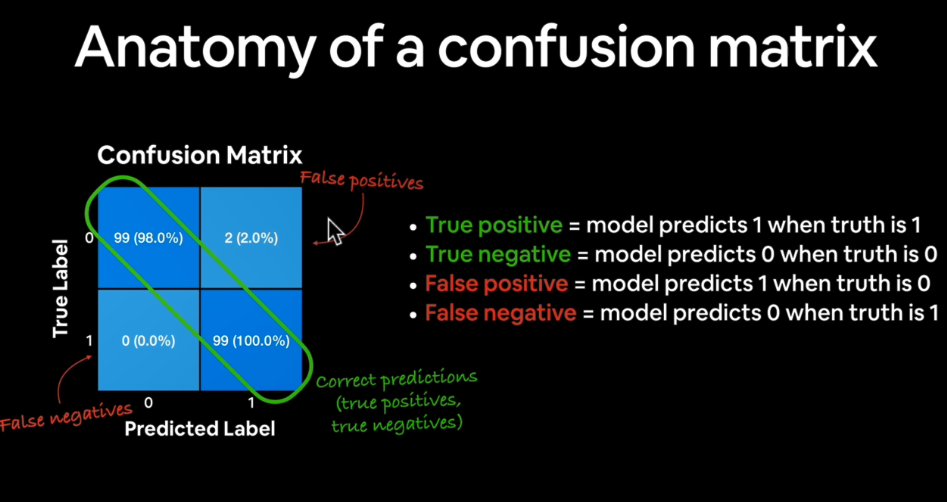

In [48]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = model_10.predict(X_test)

# Create confusion matrix
confusion_matrix(y_test, np.round(y_preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([[21, 80],
       [ 0, 99]])

Oops... looks like our predictions array has come out in **prediction probability** form... the standard output from the sigmoid (or softmax) activation functions. that's why we used `tf.round(y_preds)` in below code.

In [49]:
y_test[:2],y_preds[:2]

(array([1, 1]),
 array([[0.549279],
        [0.549279]], dtype=float32))

<h1 style="color:red">lec 023:-Making our confusion matrix prettier.mp4</h1>

How about we prettify our confusion matrix?

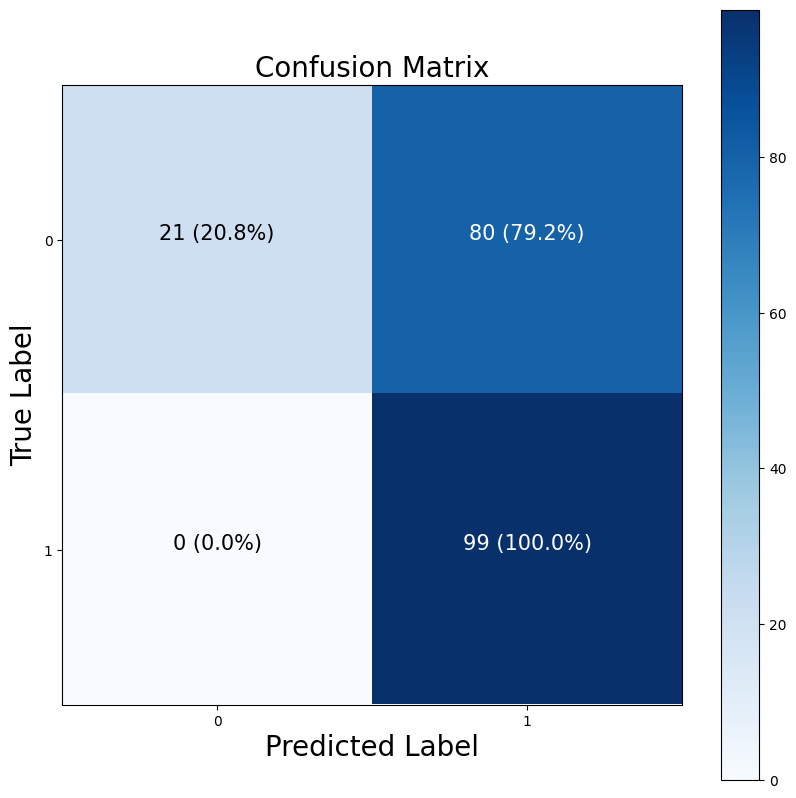

In [50]:
# Note: the confusion matrix code we're about to write is a remix of scikit-learn's plot_confusion_matrix
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

import itertools

figsize = (10,10)

# Create the confusion matrix
cm = confusion_matrix(y_test, np.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:,np.newaxis] # normalize our confusion matrix

n_classes = cm.shape[0]

# Let's prettify it
fig, ax = plt.subplots(figsize=figsize)
# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues)
fig.colorbar(cax)

# Create classes
classes = False

if classes:
  lables = classes
else:
  labels = np.arange(cm.shape[0])

# Label the axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted Label",
       ylabel="True Label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)

# set the threshold for different colors
threshold = (cm.max() + cm.min())/2.

# Plot the text on each cell
for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
  plt.text(j,i,f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
           horizontalalignment ="center",
           color="white" if cm[i,j]> threshold else "black",
           size=15)

Here is a **clear, rigorous explanation** of that line, broken down step-by-step and mathematically.

---

## Code

```python
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
```

---

## What this line does (high level)

It **row-normalizes the confusion matrix** so that:

* Each row sums to **1**
* Each cell becomes a **percentage / probability**
* You can interpret values as
  **“given the true class, how often was each class predicted?”**

This converts raw counts → normalized proportions.

---

## What `cm` is (assumed)

`cm` is a **confusion matrix** of shape:

```
(n_classes, n_classes)
```

Example:

```python
cm =
[[50,  2,  3],
 [ 5, 40,  5],
 [ 1,  4, 45]]
```

* Rows → **true labels**
* Columns → **predicted labels**

---

## Line-by-line breakdown

### 1. `cm.astype("float")`

```python
cm.astype("float")
```

* Converts integers to floating-point numbers
* Required because division with integers can truncate or behave unexpectedly
* Ensures **decimal values** are preserved

Example:

```python
[[50., 2., 3.],
 [ 5.,40., 5.],
 [ 1., 4.,45.]]
```

---

### 2. `cm.sum(axis=1)`

```python
cm.sum(axis=1)
```

* Sums **each row**
* Produces total samples per **true class**

Example:

```python
[55, 50, 50]
```

Mathematically:
[
\text{row_sum}*i = \sum_j cm*{i,j}
]

---

### 3. `[:, np.newaxis]`

```python
cm.sum(axis=1)[:, np.newaxis]
```

* Converts shape from:

  ```
  (n_classes,) → (n_classes, 1)
  ```
* Required for **broadcasting** during division

Example:

```python
[[55],
 [50],
 [50]]
```

Without this, NumPy cannot align dimensions correctly.

---

### 4. Division (broadcasting)

```python
cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
```

* Each row is divided by its own sum
* Broadcasting applies the division **row-wise**

Example result:

```python
[[0.91, 0.036, 0.054],
 [0.10, 0.80 , 0.10 ],
 [0.02, 0.08 , 0.90 ]]
```

---

## Mathematical meaning

Each element becomes:

[
cm_{\text{norm}}[i, j] =
\frac{cm[i, j]}{\sum_j cm[i, j]}
]

Interpretation:

> **Given the true class = i, what fraction of samples were predicted as class j?**

---

## Why row normalization is used

* Rows = **ground truth**
* Row normalization answers:

  * *“How well does the model perform per class?”*
* Makes class-wise performance comparable even with class imbalance

---

## What each value represents

* Diagonal values → **class-wise accuracy**
* Off-diagonal → **confusion between classes**
* Each row sums to **1**

---

## One-line documentation summary

> This line normalizes the confusion matrix row-wise, converting raw counts into per-class prediction probabilities using NumPy broadcasting.

---

If you want next:

* Column normalization vs row normalization
* Visual interpretation in a heatmap
* Why this is preferred over overall accuracy

Say the word.


<h1 style="color:red">lec 024:-Putting things together with multi-class classification part 1_ Getting the data.mp4</h1>

# Working with a larger example (multiclass classification)

When you have more than two classes as an option, it's known as **multi-class classification**.

To practice multi-class classification, we're going to build a neural network to classify images of different items of clothing.

In [51]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data,train_labels), (test_data,test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [52]:
# Show the first training example
print(f"Training sample:\n{train_data[0]}")
print(f"Training label:\n{train_labels[0]}")

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [53]:
# Check the shape of a single example
train_data[0].shape,train_labels[0].shape

((28, 28), ())

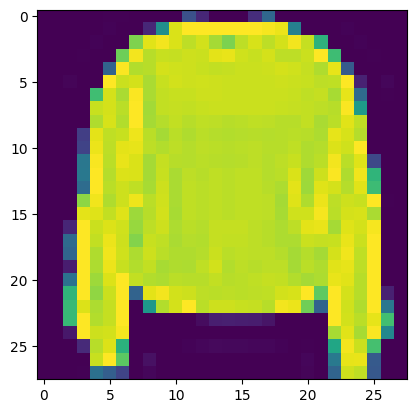

In [54]:
# Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7]);

In [55]:
# Check out samples label
train_labels[7]

np.uint8(2)

<h1 style="color:red">lec 025:-Multi-class classification part 2_ Becoming one with the data.mp4</h1>

In [56]:
# Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
len(class_names)

10

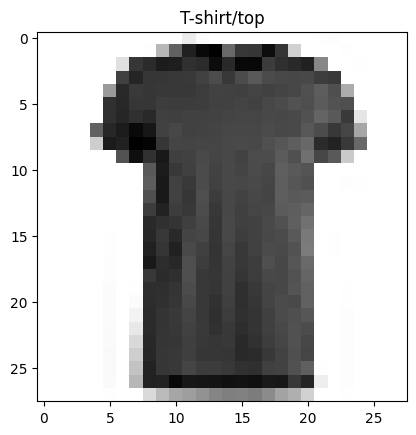

In [57]:
# Plot an example image and its label
index_of_choice = 17
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])
plt.show()

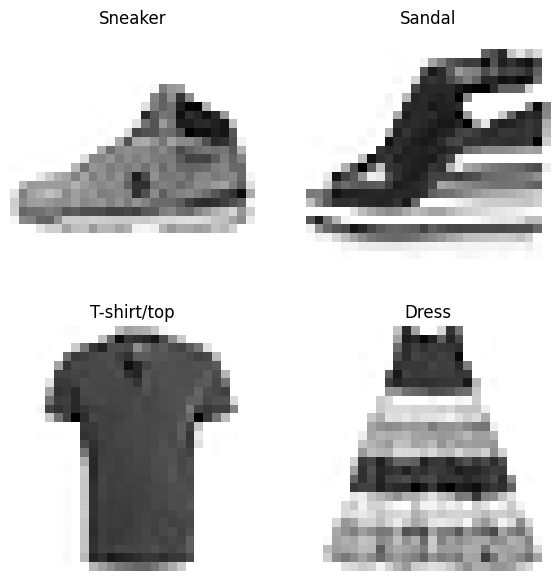

In [58]:
# Plot multiple random images of fashion MNIST

import random
plt.figure(figsize=(7,7))
for i in range(4):
  ax = plt.subplot(2,2,i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index],cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

<h1 style="color:red">lec 026:-Multi-class classification part 3_ Building a multi-class classification model.mp4</h1>

`tf.unique(train_labels)` finds the **unique values** in a TensorFlow tensor and returns them (plus how to reconstruct the original tensor).

---

## What `tf.unique` does

```python
tf.unique(x)
```

* Input: **1D tensor**
* Output: **two tensors**

  1. `y` → unique values (in order of first appearance)
  2. `idx` → indices to reconstruct `x` from `y`

---

## Applied to your case

```python
unique_labels, idx = tf.unique(train_labels)
```

### Meaning:

* `unique_labels`: the distinct class labels present in `train_labels`
* `idx`: for each element in `train_labels`, tells which index in `unique_labels` it maps to

---

## Example

```python
train_labels = tf.constant([3, 1, 3, 2, 1])
y, idx = tf.unique(train_labels)
```

Results:

```python
y   = [3, 1, 2]
idx = [0, 1, 0, 2, 1]
```

Reconstruction logic:

```python
y[idx] == train_labels
```

---

## Shape constraints (important)

* Input **must be 1D**
* If labels are 2D, flatten first:

```python
tf.unique(tf.reshape(train_labels, [-1]))
```

---

## How to get only the number of classes

```python
num_classes = tf.shape(tf.unique(train_labels).y)[0]
```

Or (eager mode):

```python
len(tf.unique(train_labels).y)
```

---

## Difference vs NumPy

| Function    | Order preserved | Graph-safe |
| ----------- | --------------- | ---------- |
| `tf.unique` | Yes             | Yes        |
| `np.unique` | No (sorted)     | No         |

TensorFlow keeps **first occurrence order**, NumPy sorts.

---

## One-line documentation summary

> `tf.unique` returns the distinct values in a 1D tensor along with indices that map the original tensor to those unique values, preserving order of first appearance.

If you want next:

* `tf.unique_with_counts`
* Why order preservation matters in label encoding
* Difference between `tf.unique` and `sklearn.LabelEncoder`


## Building a multi-class classification model

For our multi-class classification model, we can use a similar architecture to our binary classifiers, however, we're going to have to tweak a few things:
* Input shape: 28 x 28 (the shape of one image)
* Output shape = 10 (one per class of clothing)
* Loss function = tf.keras.losses.CategoricalCrossentropy()
  * If your labels are one-hot encoded, use `CategoricalCrossentropy()`
    * For one-hot encoding you can use `tf.one_hot(train_labels,depth=(tf.unique(train_labels).[0]))`
  * If your labels are integer form use `SparseCategoricalCrossentropy()`
* Outout layer activation = Softmax (not sigmoid)

In [59]:
# Our data has to be flattened from (28,28) to (None,784) where None is for batch_size
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])

flatten_model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [60]:
28*28

784

**Note:** `CategoricalCrossentropy` loss expect labels in one-hot-encoding but if you are providing integer values in labels then use `SparseCategoricalCrossentropy` loss.

In [61]:
# We can convert our labels to one-hot-encoding by
tf.one_hot(train_labels,depth=10)[:11]  # for only 11 rows

<tf.Tensor: shape=(11, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)>

In [62]:
tf.unique(train_labels)

Unique(y=<tf.Tensor: shape=(10,), dtype=uint8, numpy=array([9, 0, 3, 2, 7, 5, 1, 6, 4, 8], dtype=uint8)>, idx=<tf.Tensor: shape=(60000,), dtype=int32, numpy=array([0, 1, 1, ..., 2, 1, 5], dtype=int32)>)

In [63]:
if True:
  # Set random seed
  tf.random.set_seed(42)

  # Create the model
  model_11 = tf.keras.Sequential([
      tf.keras.layers.Flatten(input_shape=(28,28)),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(10,activation = "softmax")
  ])

  # Compile the model
  model_11.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                   optimizer = tf.keras.optimizers.Adam(),
                   metrics=["accuracy"]
  )

  # Fit the model
  non_norm_history = model_11.fit(train_data,
                                  train_labels,
                                  epochs=10,
                                  validation_data=(test_data,test_labels)
  )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0995 - loss: 3.4638 - val_accuracy: 0.1000 - val_loss: 2.3031
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0995 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0988 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3025
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - 

<h1 style="color:red">lec 027:-Multi-class classification part 4_ Improving performance with normalisation.mp4</h1>

In [64]:
# Check the model summary
model_11.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

### Standardization vs Normalization — Summary Table

| Aspect                  | Standardization (Z-score)              | Normalization (Min–Max)                      |
| ----------------------- | -------------------------------------- | -------------------------------------------- |
| Formula                 | (x' = \frac{x - \mu}{\sigma})          | (x' = \frac{x - x_{min}}{x_{max} - x_{min}}) |
| Output mean             | 0                                      | Depends on data                              |
| Output std              | 1                                      | Depends on data                              |
| Output range            | Unbounded                              | Fixed, usually ([0,1])                       |
| Sensitivity to outliers | Low–Moderate                           | High                                         |
| Distribution shape      | Preserved                              | Preserved                                    |
| Typical use             | Linear models, SVM, PCA, k-means       | Neural networks, bounded inputs              |
| When to prefer          | Unknown distribution, outliers present | Known bounds required                        |

---

### TensorFlow — Apply and Undo

#### Standardization

**Apply**

```python
mean = tf.reduce_mean(x, axis=0)
std  = tf.math.reduce_std(x, axis=0)
x_std = (x - mean) / std
```

**Undo (Inverse transform)**

```python
x_orig = x_std * std + mean
```

**Keras utility**

```python
layer = tf.keras.layers.Normalization()
layer.adapt(x)
x_std = layer(x)
```

*Undo:* store `layer.mean` and `layer.variance`, then apply inverse manually.

---

#### Normalization (Min–Max)

**Apply**

```python
xmin = tf.reduce_min(x, axis=0)
xmax = tf.reduce_max(x, axis=0)
x_norm = (x - xmin) / (xmax - xmin)
```

**Undo (Inverse transform)**

```python
x_orig = x_norm * (xmax - xmin) + xmin
```

**Keras utility**

```python
layer = tf.keras.layers.Rescaling(scale=1./(xmax - xmin), offset=-xmin/(xmax - xmin))
x_norm = layer(x)
```

*Undo:* invert using stored `xmin`, `xmax`.

---

### Implementation Rule

Always store parameters (`mean`, `std`, `xmin`, `xmax`) from training data. Use the same parameters for validation, test, and inverse transforms.


In [65]:
# Check the min and max values of the training data
train_data.min(),train_data.max()

(np.uint8(0), np.uint8(255))

Neural networks prefer data to be scaled (or normalized), this means they like to have the numbers in the tensors they try to find patterns between 0 and 1.

In [66]:
# We can get our training and testing data between 0 & 1 by dividing by the maximum
train_data_norm = train_data/255.0
test_data_norm = test_data/255.0

# Check the min and max values of the scaled training data
train_data_norm.min(),train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [67]:
# Now our data is normalized, let's build a model to find patterns in it

if True:
  # Set random seed
  tf.random.set_seed(42)

  # Create the model
  model_12 = tf.keras.Sequential([
      tf.keras.layers.Flatten(input_shape=(28,28)),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(10,activation = "softmax")
  ])

  # Compile the model
  model_12.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                   optimizer = tf.keras.optimizers.Adam(),
                   metrics=["accuracy"]
  )

  # Fit the model
  norm_history = model_11.fit(train_data_norm,
                                  train_labels,
                                  epochs=10,
                                  validation_data = (test_data_norm,test_labels)
  )


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0985 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0985 - loss: 2.3028 - 

**Note:** Neural networks tend to prefer data in numerical from as well as scaled/normalized(numbers between 0 & 1).

<h1 style="color:red">lec 028:-Multi-class classification part 5_ Comparing normalised and non-normalised data.mp4</h1>

<Axes: title={'center': 'Normalized data'}>

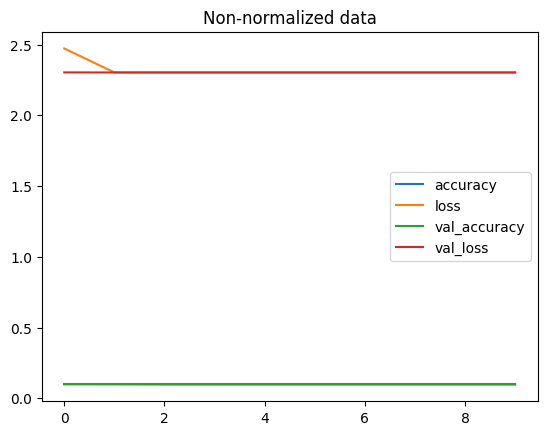

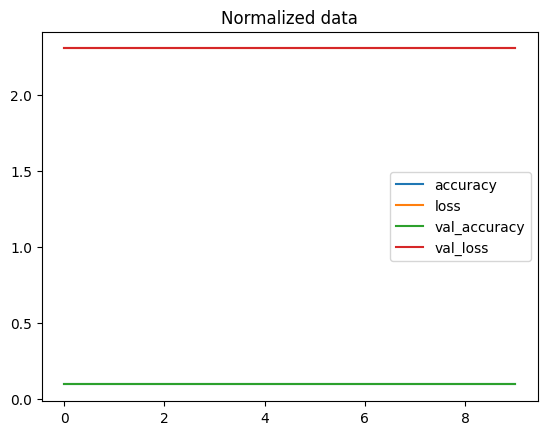

In [68]:
import pandas as pd
# Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")
# Plot normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized data")

> **Note:** The same model with even *slightly* different data can produce *dramatically* different results. So when you're comparing models, it's important to make sure you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture).

<h1 style="color:red">lec 029:-Multi-class classification part 6_ Finding the ideal learning rate.mp4</h1>

## Finding the ideal learning rate

In [69]:
# Set random seed
tf.random.set_seed(42)

# Create model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

# Compile model
model_13.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

# Create the learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

# Fit the model
find_lr_history = model_13.fit(train_data_norm,
                              train_labels,
                               epochs=40,
                               validation_data=(test_data_norm,test_labels),
                               callbacks=[lr_scheduler])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3629 - loss: 1.7007 - val_accuracy: 0.6700 - val_loss: 0.9014 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6921 - loss: 0.8306 - val_accuracy: 0.7496 - val_loss: 0.7035 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7604 - loss: 0.6766 - val_accuracy: 0.7698 - val_loss: 0.6387 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7761 - loss: 0.6298 - val_accuracy: 0.7768 - val_loss: 0.6241 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7808 - loss: 0.6148 - val_accuracy: 0.7790 - val_loss: 0.6195 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7838 - loss: 0.6075 - val_accuracy: 0.7812 - val_loss: 0.6154 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7850 - l

Text(0.5, 1.0, 'Find the ideal learning rate')

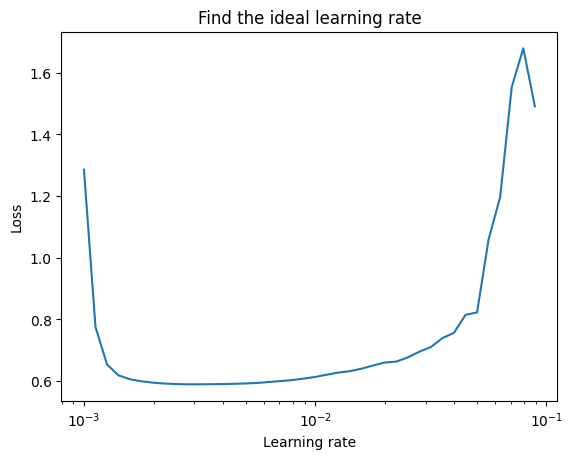

In [70]:
# Plot the learning rate decay curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

lrs = 1e-3*10**(tf.range(40)/20)

plt.semilogx(lrs,find_lr_history.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Find the ideal learning rate")

In [84]:
# Let's refit a model with the ideal learning rate

if True:
  # Set random seed
  tf.random.set_seed(42)

  # Create the model
  model_14 = tf.keras.Sequential([
      tf.keras.layers.Flatten(input_shape=(28,28)),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(4,activation = "relu"),
      tf.keras.layers.Dense(10,activation = "softmax")
  ])

  # Compile the model
  model_14.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                   optimizer = tf.keras.optimizers.Adam(learning_rate=0.002),
                   metrics=["accuracy"]
  )

  # Fit the model
  history_14 = model_14.fit(train_data_norm,
                            train_labels,
                            epochs=20,
                            validation_data = (test_data_norm,test_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4498 - loss: 1.4683 - val_accuracy: 0.7335 - val_loss: 0.7296
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7457 - loss: 0.6856 - val_accuracy: 0.7704 - val_loss: 0.6434
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7727 - loss: 0.6153 - val_accuracy: 0.7799 - val_loss: 0.6126
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7857 - loss: 0.5899 - val_accuracy: 0.7934 - val_loss: 0.5946
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7955 - loss: 0.5732 - val_accuracy: 0.8016 - val_loss: 0.5792
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8028 - loss: 0.5610 - val_accuracy: 0.8029 - val_loss: 0.5741
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8057 - loss: 0.5507 - val_accuracy: 0.8058 - val_loss: 0.5671
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8091 - loss: 0.5430 -

<h1 style="color:red">lec 030:-Multi-class classification part 7_ Evaluating our model.mp4</h1>

## Evaluating our multi-class classification model

To evaluate our multi-class classifictaion model we could:
* Evaluate its performance using other classification metrics (such as confusion matrix)
* Assess some of its predictions (through visualizations)
* Improve its results (by training it for longer or changing the architecture)
* Save and export it for use in an application

Let's go through the top 2...

In [85]:
# Create a confusion matrix
import itertools
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def make_confusion_matrix(y_true,y_preds,classes=None,figsize = (10,10),text_size=15):
  # Create the confusion matrix
  cm = confusion_matrix(y_true, y_preds)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:,np.newaxis] # normalize our confusion matrix

  n_classes = cm.shape[0]

  # Let's prettify it
  fig, ax = plt.subplots(figsize=figsize)
  # Create a matrix plot
  cax = ax.matshow(cm, cmap=plt.cm.Blues)
  fig.colorbar(cax)

  # Set labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels)

  # Set x-axis labels to bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Adjust label size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)

  # set the threshold for different colors
  threshold = (cm.max() + cm.min())/2.

  # Plot the text on each cell
  for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
    plt.text(j,i,f"{cm[i,j]} ({cm_norm[i,j]*100:.1f}%)",
            horizontalalignment ="center",
            color="white" if cm[i,j]> threshold else "black",
            size=15)

In [86]:
# Make some predictions with our model
y_probs = model_14.predict(test_data_norm) # probs is short for "prediction probabilities"

# view the first 5 predictions
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[9.58432338e-06, 1.97886699e-17, 1.81601414e-10, 3.66730623e-15,
        2.26335462e-16, 1.09707065e-01, 4.31497938e-07, 1.84117571e-01,
        1.63829952e-06, 7.06163764e-01],
       [2.61618843e-05, 6.79862590e-12, 9.70572174e-01, 4.06772073e-04,
        1.44835236e-02, 4.55022071e-20, 1.45107890e-02, 1.61032122e-35,
        4.36333153e-07, 2.39656506e-11],
       [1.14508214e-06, 9.99453187e-01, 5.34225171e-13, 5.45552000e-04,
        1.03028008e-09, 0.00000000e+00, 4.65665909e-11, 0.00000000e+00,
        7.72053254e-29, 2.08419150e-23],
       [5.52882454e-07, 9.98305559e-01, 2.22917333e-13, 1.69398636e-03,
        1.80894155e-09, 0.00000000e+00, 1.43805107e-11, 0.00000000e+00,
        3.43755661e-32, 4.78334284e-26],
       [2.42143333e-01, 3.96637106e-03, 1.57936811e-01, 1.78228334e-01,
        2.42664367e-02, 8.17143189e-07, 3.92836899e-01, 6.71318889e-10,
        6.14686636e-04, 6.31958937e-06]], dtype=float32)

> **Note:** Remember to make predictions on the same kind of data your model was trained on (e.g. if your model was trained on normalized data, you want to make predictions on normalized data).

In [87]:
y_probs[0], tf.argmax(y_probs[0]), class_names[tf.argmax(y_probs[0])]

(array([9.58432338e-06, 1.97886699e-17, 1.81601414e-10, 3.66730623e-15,
        2.26335462e-16, 1.09707065e-01, 4.31497938e-07, 1.84117571e-01,
        1.63829952e-06, 7.06163764e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankle boot')

In [88]:
# Convert all of the prediction probabilities into integers
y_preds = y_probs.argmax(axis=1)

# view the first 10 prediction labels
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 6, 6, 5, 7])

In [89]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [90]:
model_14.evaluate(train_data_norm,train_labels)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8258 - loss: 0.4964


[0.4971645176410675, 0.8242833614349365]

In [91]:
type(train_data_norm)

numpy.ndarray

In [92]:
confusion_matrix(y_true=test_labels,y_pred=y_preds)

array([[738,   3,  14, 115,   2,   1, 116,   2,   9,   0],
       [  2, 931,   2,  53,   1,   0,  10,   0,   1,   0],
       [ 11,   0, 753,  28, 102,   0, 103,   0,   3,   0],
       [ 20,  15,  24, 845,  24,   0,  67,   0,   5,   0],
       [  0,   0, 144,  59, 680,   0, 111,   0,   6,   0],
       [  0,   0,   0,   0,   0, 910,   1,  46,   9,  34],
       [130,   2, 149,  80, 145,   0, 475,   0,  19,   0],
       [  0,   0,   0,   0,   0,  40,   0, 933,   0,  27],
       [  3,   0,   3,   3,   5,  10,  53,   5, 918,   0],
       [  0,   0,   0,   0,   0,  19,   0,  65,   1, 915]])

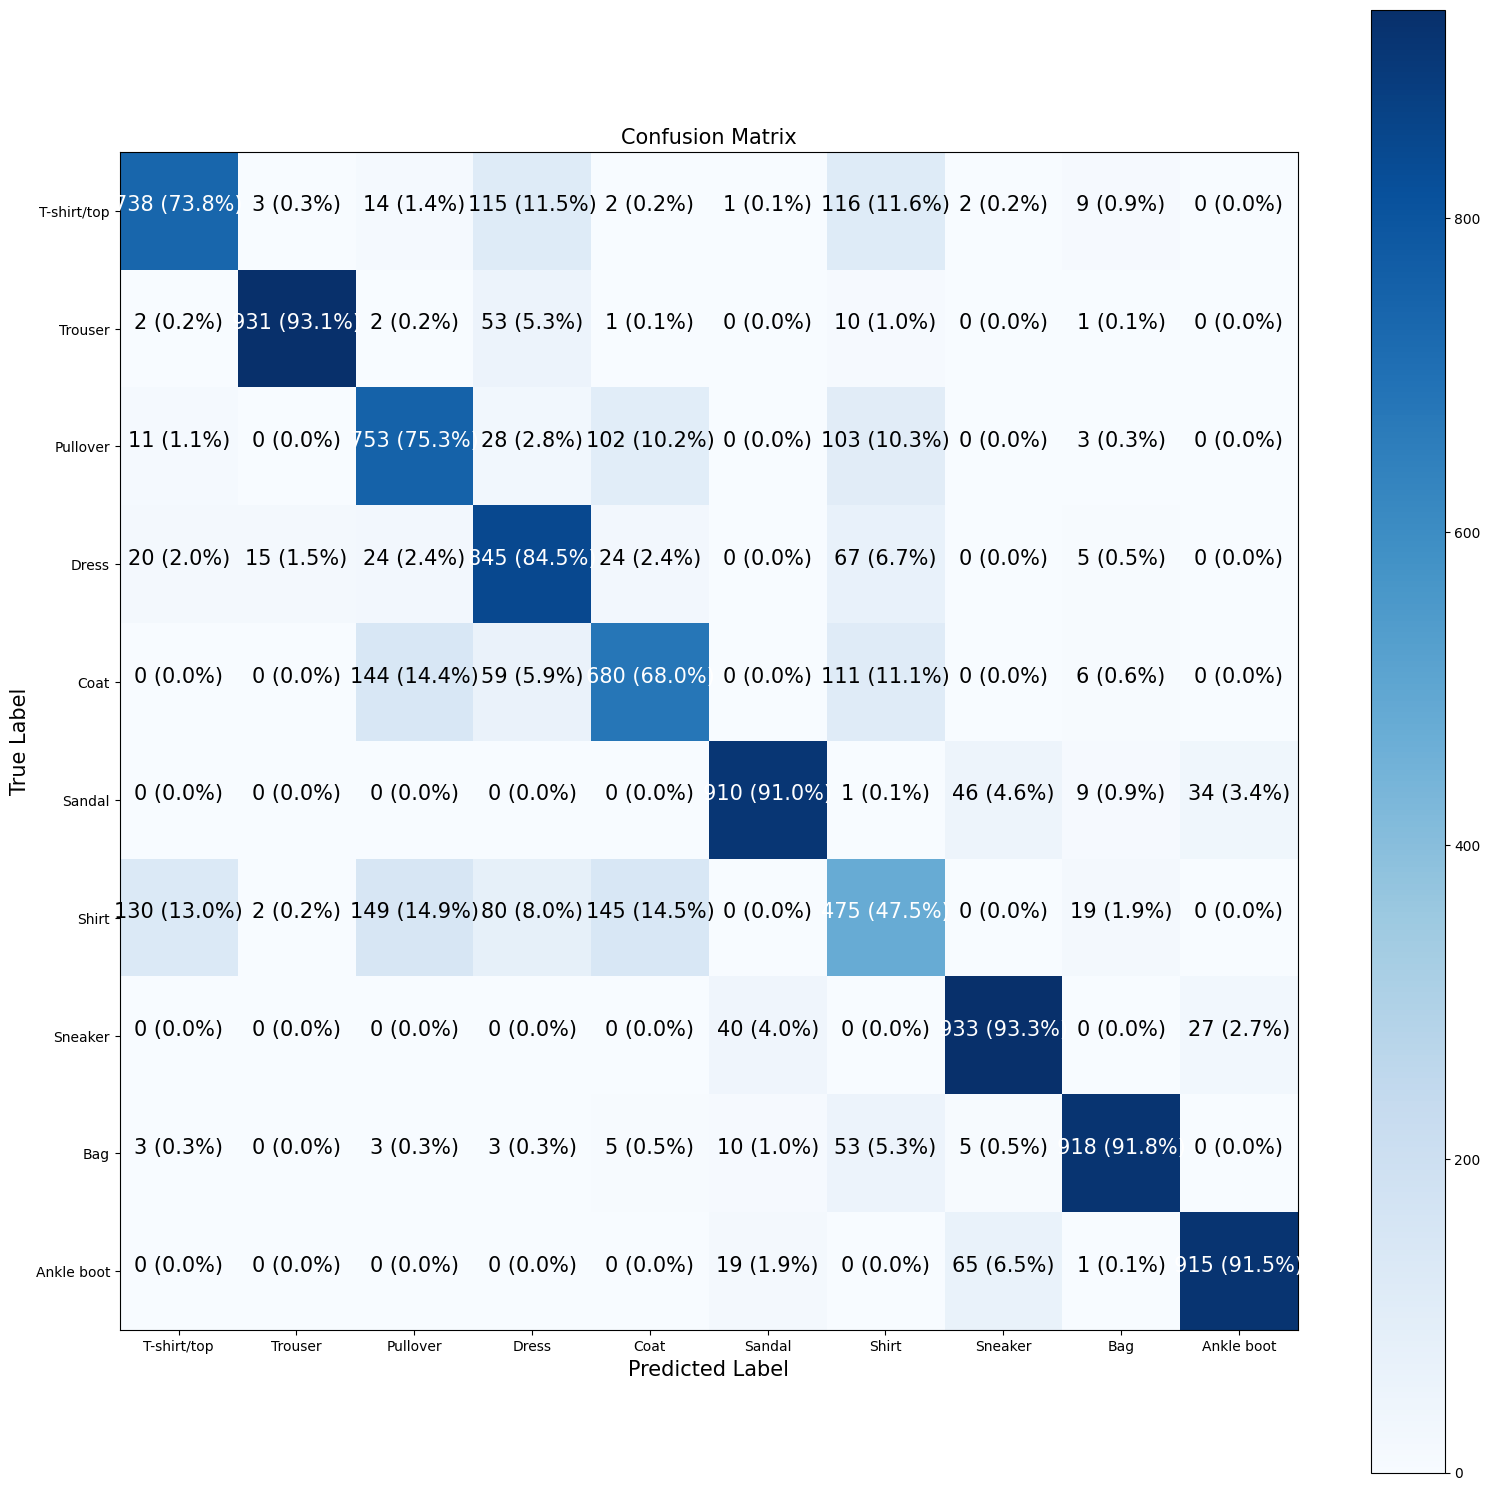

In [93]:
# Make a prettier confusion matrix
make_confusion_matrix(y_true=test_labels,y_preds=y_preds,classes=class_names,figsize=(19,19))

<h1 style="color:red">lec 032:-Multi-class classification part 9_ Visualising random model predictions.mp4</h1>

> **Note:** Often when working with images and other forms of visual data, it's a good idea to visualize as much as possible to develop a further understanding of the data and the inputs and outputs of your models.

How about we create a fun little function for:
* Plot a random image
* Make a prediction on said image
* Label the plot with the truth label & the predicted label

In [94]:
import random

def plot_random_image(model,images,true_labels,classes):
  """
  Picks a random image, plots it and labels it with the prediction and truth label
  """
  # Set up random integer
  i = random.randint(0,len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1,28,28))
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the image
  plt.imshow(target_image,cmap=plt.cm.binary)

  # Change the color of the titles depending on if the predcition is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add Xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # Set the color to green or red based on if prediction is right or wrong



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


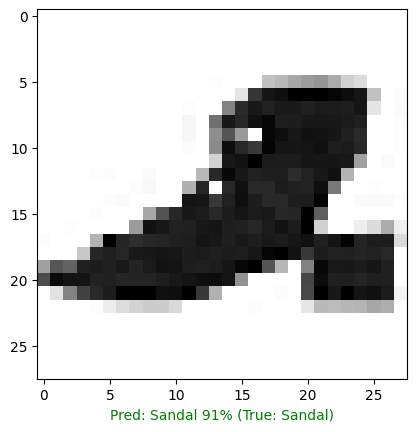

In [95]:
# Check out a random image as well as its prediction
plot_random_image(model=model_14,
                  images=test_data_norm,
                  true_labels=test_labels,
                  classes = class_names)

<h1 style="color:red">lec 033:-What _patterns_ is our model learning.mp4</h1>

## What patterns is our model learning?

In [96]:
# Find the layers of our most recent model
model_14.layers

[<Flatten name=flatten_6, built=True>,
 <Dense name=dense_30, built=True>,
 <Dense name=dense_31, built=True>,
 <Dense name=dense_32, built=True>]

In [98]:
# Extract a particular layer
model_14.layers[1]

<Dense name=dense_30, built=True>

In [100]:
# Get the patterns of a layer in our network
weights, biases = model_14.layers[1].get_weights()

# Shapes
weights,weights.shape

(array([[-1.0611295e+00, -3.9856080e-02, -2.8644317e-01,  8.9776755e-04],
        [ 3.0006913e-03,  2.3472522e-01, -3.0272177e-01,  1.1028504e+00],
        [-8.0152684e-01, -9.3438677e-02, -1.3651401e+00,  4.0980056e-01],
        ...,
        [ 4.0916184e-01,  1.0869513e+00, -7.3776424e-01,  3.4072667e-01],
        [ 5.0744772e-01,  1.4182879e+00, -8.1486768e-01,  7.7129439e-02],
        [ 4.3575425e-02,  8.2614887e-01, -8.0996543e-01,  1.3433537e+00]],
       dtype=float32),
 (784, 4))

In [101]:
# 784 from flattens no. of inputs and 4 is no. of neurons (hidden units) in our layer (784,4) shape
model_14.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

Now let's check out the bias vector...

In [103]:
# Bias and biases shape
biases,biases.shape

(array([0.5623872 , 1.9139293 , 0.54139113, 0.976058  ], dtype=float32), (4,))

Every neuron has a bias vector. Each of these is paired with a weights matrix.

The bias vector get initialized as zeros (at least in the case of a TensorFlow Dense layer).

The bias vector dictates how much the patterns within the corresponding weights matrix should influence the next layer.

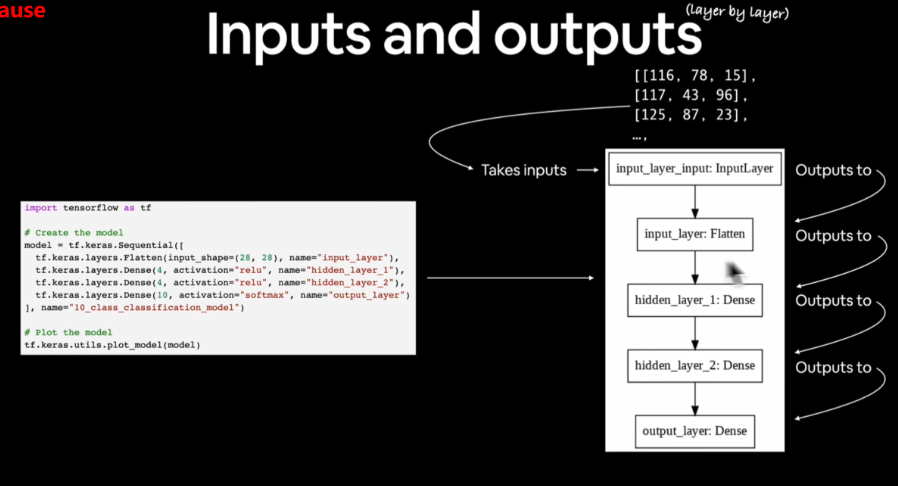

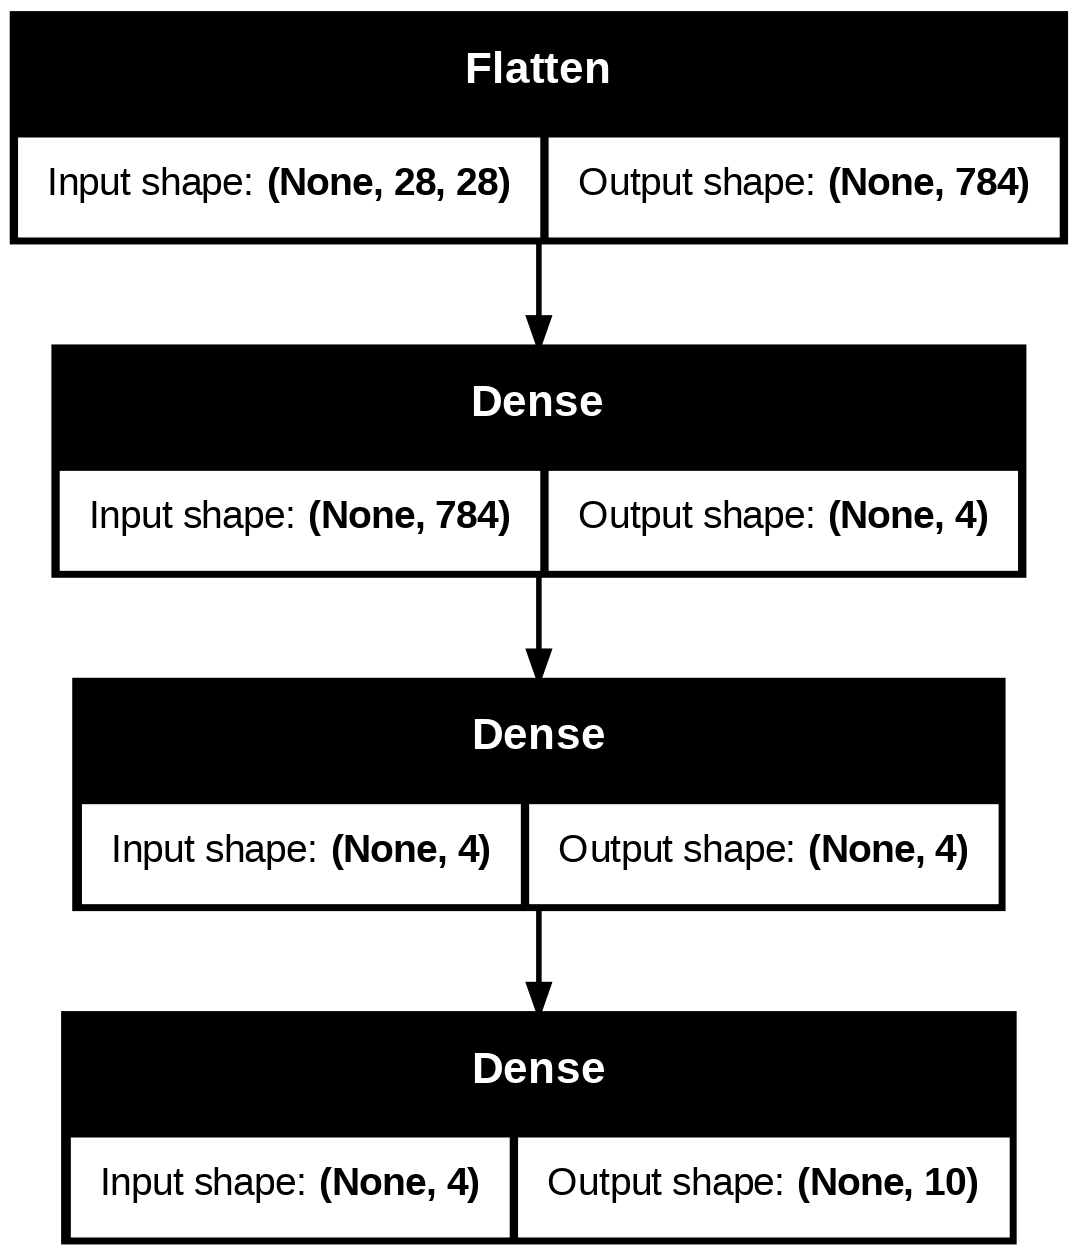

In [104]:
# Let's check out another way of veiwing our deep learning models
from tensorflow.keras.utils import plot_model
# See the inputs and outputs of each layer
plot_model(model_14,show_shapes=True)

## **Next:** check out exercises and extra curriculum...

<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Consider it classified!</p><p>Well, not classified in the sense it’s a secret, classified in the sense you’ve now built nearly a dozen (did you count them all?) neural network classification models with TensorFlow!</p><p>And on top of that, you learned about the power of non-linearity (non-straight lines), one of the key ingredients for neural networks to find patterns in non-linear (non-straight) data.</p><p>By now you should be able to:</p><ul><li><p>Describe what a classification problem is</p></li><li><p>Describe the input and output shapes of a classification problem</p></li><li><p>Build a neural network in TensorFlow to solve binary and multi-class classification problems</p></li></ul><p>The videos contained a bunch of information about the above but now it’s time to practice your skills.</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course Materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>I’d recommend going through these <strong>before</strong> moving onto the next module.</p><p>Because although the videos may be teaching you a lot, nothing will teach you more than writing more code.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-02-neural-network-classification-with-tensorflow-exercises" rel="noopener noreferrer" target="_blank">Neural Network Classification with TensorFlow Exercises &amp; Extra-curriculum</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> Think of a classification problem you’d like to work on. What are the input shapes (and information to feed to your model)? What are the ideal output shapes (what should your model classify)? Can you find an existing example of this problem online?</p><p>Send a message with your answer(s) to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to hear them!</p><p>See you in the next module!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>